In [43]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import opinf

# Import from core and local modules
from core import summarize_experiment, save_paper_figure
import config
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3

# ============================================================================
# SET RANDOM SEEDS IMMEDIATELY AFTER IMPORTS
# This ensures reproducible data generation across runs
# ============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

#### Setup

In [44]:
# Configuration
training_span = (0, 1)
num_samples = 65
noiselevel = 0.08
num_regression_points = 150
numPODmodes = 5
ndraws = 200
normalization = 1e-4
gp_normalization = 1e-4
VERBOSE = True

# Paper figure generation
SAVE_PAPER_FIGURES = False         # Set True to save publication figures
PAPER_SCENARIO = "dense_low"      # Scenario tag: dense_low, dense_high, sparse_med/medium, etc.
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"


In [45]:
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)
num_initial_conditions = len(config.input_parameters)


### Generate & Visualize Data

In [46]:
# Report experiment setup
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=normalization,
    ndraws=ndraws,
    figures_path="figures",
)

# Generate training data for multiple trajectories
sampler = step1.TrajectorySampler(
    training_span,
    num_samples,
    noiselevel,
    num_regression_points,
    synced=False,
)
(
    true_states,
    time_domain_sampled,
    snapshots_sampled,
    training_inputs,
) = sampler.multisample(config.input_parameters, plot=False)

# Generate test trajectory
(
    true_states_new_initial,
    time_domain_sampled_new_initial,
    snapshots_sampled_new_initial,
    training_inputs_new_initial,
) = sampler.sample(config.test_parameters)

time_domain = config.time_domain

# Convert to arrays
true_states = np.array(true_states)
time_domain_sampled = np.array(time_domain_sampled)
snapshots_sampled = np.array(snapshots_sampled)
training_inputs = np.array(training_inputs)

print(f"Data shapes: true_states={true_states.shape}, snapshots={snapshots_sampled.shape}")


EXPERIMENTAL SCENARIO
Data: 65 uniformly sampled snapshots over 0.00 ≤ t < 1.00 with 8.00% noise
Dimension: retaining 5 POD modes
Training: using 150 regression points
GP regularization: eta = 1.00e-04
Posterior: 200 draws

Data shapes: true_states=(5, 500, 500), snapshots=(5, 500, 65)


### Fit Basis

reducing noisy training states to 5 dimensions...done in 0.04 s.
(5, 5, 65) (5, 65) (5, 65) (65,)


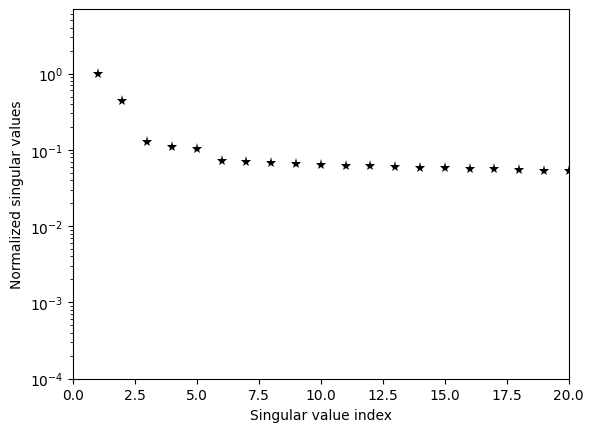

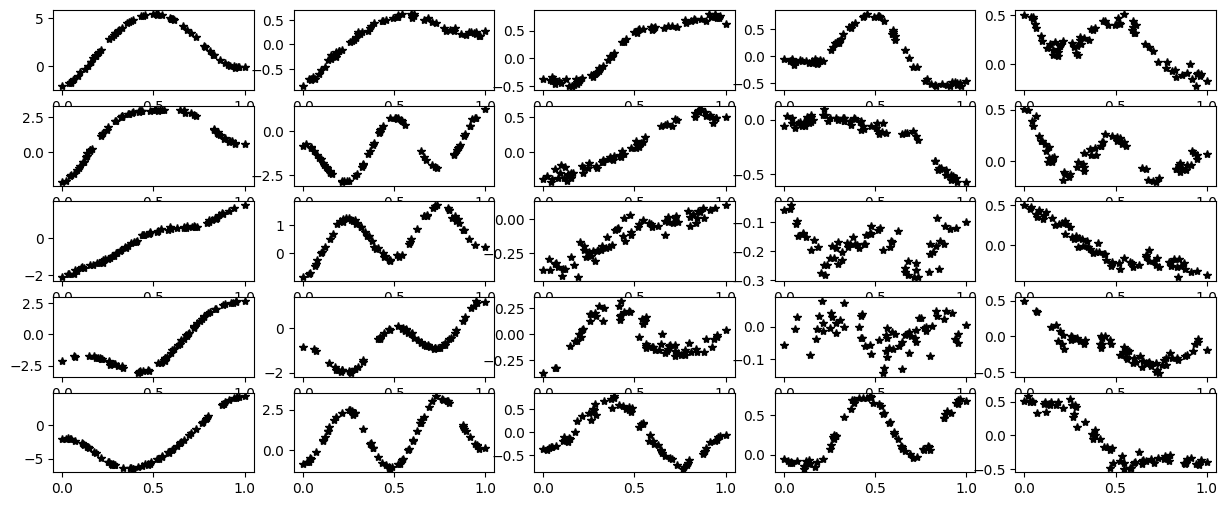

In [47]:
import time
start_time = time.time()

# Start Cell
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(np.hstack(snapshots_sampled))
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    # utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = [basis.compress(Q) for Q in snapshots_sampled]
    full_states_compressed = [basis.compress(Q) for Q in true_states]
    snapshots_compressed_new_initial = basis.compress(snapshots_sampled_new_initial)
    full_states_compressed_new_initial = basis.compress(true_states_new_initial)

snapshots_compressed = np.array(snapshots_compressed)
full_states_compressed = np.array(full_states_compressed)
snapshots_compressed_new_initial = np.array(snapshots_compressed_new_initial)
full_states_compressed_new_initial = np.array(full_states_compressed_new_initial)
print(snapshots_compressed.shape, time_domain_sampled.shape, snapshots_compressed_new_initial.shape, time_domain_sampled_new_initial.shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')

In [48]:
import step2_fitgps as step2

# Fit Gaussian process kernels to the compressed training data.
gps = []  # indexed by trajectory, then reduced mode.
for i, (t, Q) in enumerate(zip(time_domain_sampled, snapshots_compressed)):
    print(f"\n*** Trajectory {i+1} ***")
    gps.append(
        step2.fit_gaussian_processes(
            time_domain_training=sampler.training_time_domain,
            time_domain_sampled=t,
            snapshots_sampled=Q,
            gp_regularizer=gp_normalization,
        )
    )

# Extract initial conditions from GP estimates
q0s = [
    np.array([gp.state_estimate[0] for gp in gps[ell]])
    for ell in range(len(config.input_parameters))
]


*** Trajectory 1 ***

fitting GP model for state 'q0'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.3029e+01
	\ell = 2.8410e-01
	\chi = 1.4923e-03
done in 1.30 s.
computing weight matrix...done in 0.00 s.

fitting GP model for state 'q1'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.3044e-01
	\ell = 2.7375e-01
	\chi = 1.1771e-03
done in 1.34 s.
computing weight matrix...done in 0.00 s.

fitting GP model for state 'q2'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.9109e-01
	\ell = 2.1293e-01
	\chi = 1.1436e-03
done in 1.42 s.
computing weight matrix...done in 0.00 s.

fitting GP model for state 'q3'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.2336e-01
	\ell = 2.0765e-01
	\chi = 1.1890e-03
done in 1.17 s.
computin

In [49]:
q0_new_initial = np.array([gps[-1][podMode].predict(time_domain_eval_training)[0][0] for podMode in range(numPODmodes)])
q0_new_initial.shape

(5,)

In [50]:
import step3_estimate as step3

# Step 3: Construct the posterior hyperparameters -------------------------
bayesian_model = step3.estimate_posterior(
    prediction_time_domain=sampler.prediction_time_domain,
    gps=gps,
    training_inputs=training_inputs,
    initial_conditions=q0s,
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...UNSTABLE
(2/81) Testing regularizer 1.7783e-16...UNSTABLE
(3/81) Testing regularizer 3.1623e-16...UNSTABLE
(4/81) Testing regularizer 5.6234e-16...UNSTABLE
(5/81) Testing regularizer 1.0000e-15...UNSTABLE
(6/81) Testing regularizer 1.7783e-15...UNSTABLE
(7/81) Testing regularizer 3.1623e-15...UNSTABLE
(8/81) Testing regularizer 5.6234e-15...UNSTABLE
(9/81) Testing regularizer 1.0000e-14...UNSTABLE
(10/81) Testing regularizer 1.7783e-14...UNSTABLE
(11/81) Testing regularizer 3.1623e-14...UNSTABLE
(12/81) Testing regularizer 5.6234e-14...UNSTABLE
(13/81) Testing regularizer 1.0000e-13...UNSTABLE
(14/81) Testing regularizer 1.7783e-13...UNSTABLE
(15/81) Testing regularizer 3.1623e-13...UNSTABLE
(16/81) Testing regularizer 5.6234e-13...UNSTABLE
(17/81) Testing regularizer 1.0000e-12...UNSTABLE
(18/81) Testing regularizer 1.7783e-12...UNSTABLE
(19/81) Testing regularizer 3.1623e-12...UNSTABLE
(20/8

In [51]:
def draws_for_single_trajectory(params, q0, snaps_compressed):
    input_func = config.input_func_factory(params)
    qbar = snaps_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snaps_compressed - qbar), axis=1)

    num_unstables = 0
    prediction_draws_compressed = []
    training_draws_compressed = []
    for _ in range(ndraws):
        prediction_draw = bayesian_model.predict(
            q0,
            sampler.prediction_time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            q0,
            time_domain_eval_training,
            input_func=input_func,
        )
        if prediction_draw.shape[1] != sampler.prediction_time_domain.size:
            num_unstables += 1
            continue
        if np.any(np.abs(prediction_draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        prediction_draws_compressed.append(prediction_draw)
        training_draws_compressed.append(training_draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    prediction_draws_uncompressed = [basis.decompress(draw) for draw in prediction_draws_compressed]
    training_draws_uncompressed = [basis.decompress(draw) for draw in training_draws_compressed]
    return prediction_draws_compressed, prediction_draws_uncompressed, training_draws_compressed, training_draws_uncompressed

# Draw samples from the posterior (for now at the same model parameters).
with opinf.utils.TimedBlock("sampling posterior distribution"):
    all_prediction_draws_compressed, all_prediction_draws_decompressed, all_training_draws_compressed, all_training_draws_decompressed = [], [], [], []
    for ell, params in enumerate(config.input_parameters):
        prediction_draws_compressed, prediction_draws_decompressed, training_draws_compressed, training_draws_decompressed = draws_for_single_trajectory(
            params,
            q0s[ell],
            snapshots_compressed[ell],
        )
        all_prediction_draws_compressed.append(prediction_draws_compressed)
        all_prediction_draws_decompressed.append(prediction_draws_decompressed)
        all_training_draws_compressed.append(training_draws_compressed)
        all_training_draws_decompressed.append(training_draws_decompressed)
    
    prediction_draws_compressed_new_initial, prediction_draws_decompressed_new_initial, training_draws_compressed_new_initial, training_draws_decompressed_new_initial = draws_for_single_trajectory(
        config.test_parameters,
        q0_new_initial,
        snapshots_compressed_new_initial,
    )

# Step 4: plot results ----------------------------------------------------
# Initialize reduced plotter.
true_states_compressed = [basis.compress(Q) for Q in true_states]
true_states_projected = [
    basis.decompress(Q_) for Q_ in true_states_compressed
]

algo_time = time.time() - start_time
print(f"\nAlgorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")


sampling posterior distribution...done in 6.14 s.

Algorithm runtime: 48.4s (0.8min)


In [52]:
true_states_compressed_new_initial = basis.compress(true_states_new_initial)

true_states_compressed_new_initial = np.expand_dims(np.array(true_states_compressed_new_initial), axis=0)
true_states_compressed = np.array(true_states_compressed)

true_states_compressed = np.concatenate((true_states_compressed, true_states_compressed_new_initial), axis=0)

true_states_compressed.shape

(6, 5, 500)

In [53]:
import numpy as np


def truncate_draws(draws):
    # find minimum number of draws across the 5 lists
    min_draws = min(len(inner) for inner in draws)
    print("min_draws =", min_draws)

    # truncate each inner list to min_draws
    draws = [inner[:min_draws] for inner in draws]

    # optionally convert into a single numpy array:
    # result shape will be (5, min_draws, 5, 500)
    return np.permute_dims(np.stack([np.stack(inner, axis=0) for inner in draws], axis=0), (1,0,2,3)) # shape (min_draws, intial, podmodes, 500)

all_prediction_draws_compressed = truncate_draws(all_prediction_draws_compressed)
all_prediction_draws_decompressed = truncate_draws(all_prediction_draws_decompressed)
all_training_draws_compressed = truncate_draws(all_training_draws_compressed)
all_training_draws_decompressed = truncate_draws(all_training_draws_decompressed)
training_draws_compressed_new_initial = np.array(training_draws_compressed_new_initial)
prediction_draws_compressed_new_initial = np.array(prediction_draws_compressed_new_initial)


min_draws = 200
min_draws = 200
min_draws = 200
min_draws = 200


In [54]:
print(np.expand_dims(training_draws_compressed_new_initial, axis=1).shape, all_training_draws_compressed.shape)

training_draws_compressed = np.concatenate((all_training_draws_compressed, np.expand_dims(training_draws_compressed_new_initial, axis=1)[:all_training_draws_compressed.shape[0]]), axis=1)
prediction_draws_compressed = np.concatenate((all_prediction_draws_compressed, np.expand_dims(prediction_draws_compressed_new_initial, axis=1)[:all_prediction_draws_compressed.shape[0]]), axis=1)

training_draws_compressed.shape, prediction_draws_compressed.shape

(200, 1, 5, 150) (200, 5, 5, 150)


((200, 6, 5, 150), (200, 6, 5, 500))

In [55]:
lengthscales = np.array([gps[i][j].gpr.kernel_.k1.k2.length_scale for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
variances = np.array([gps[i][j].gpr.kernel_.k1.k1.constant_value for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
noises = np.array([gps[i][j].gpr.kernel_.k2.noise_level for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
print("Lengthscales shape:", lengthscales.shape)
print("Variances shape:", variances.shape)
print("Noises shape:", noises.shape)

Lengthscales shape: (1, 5, 5)
Variances shape: (1, 5, 5)
Noises shape: (1, 5, 5)


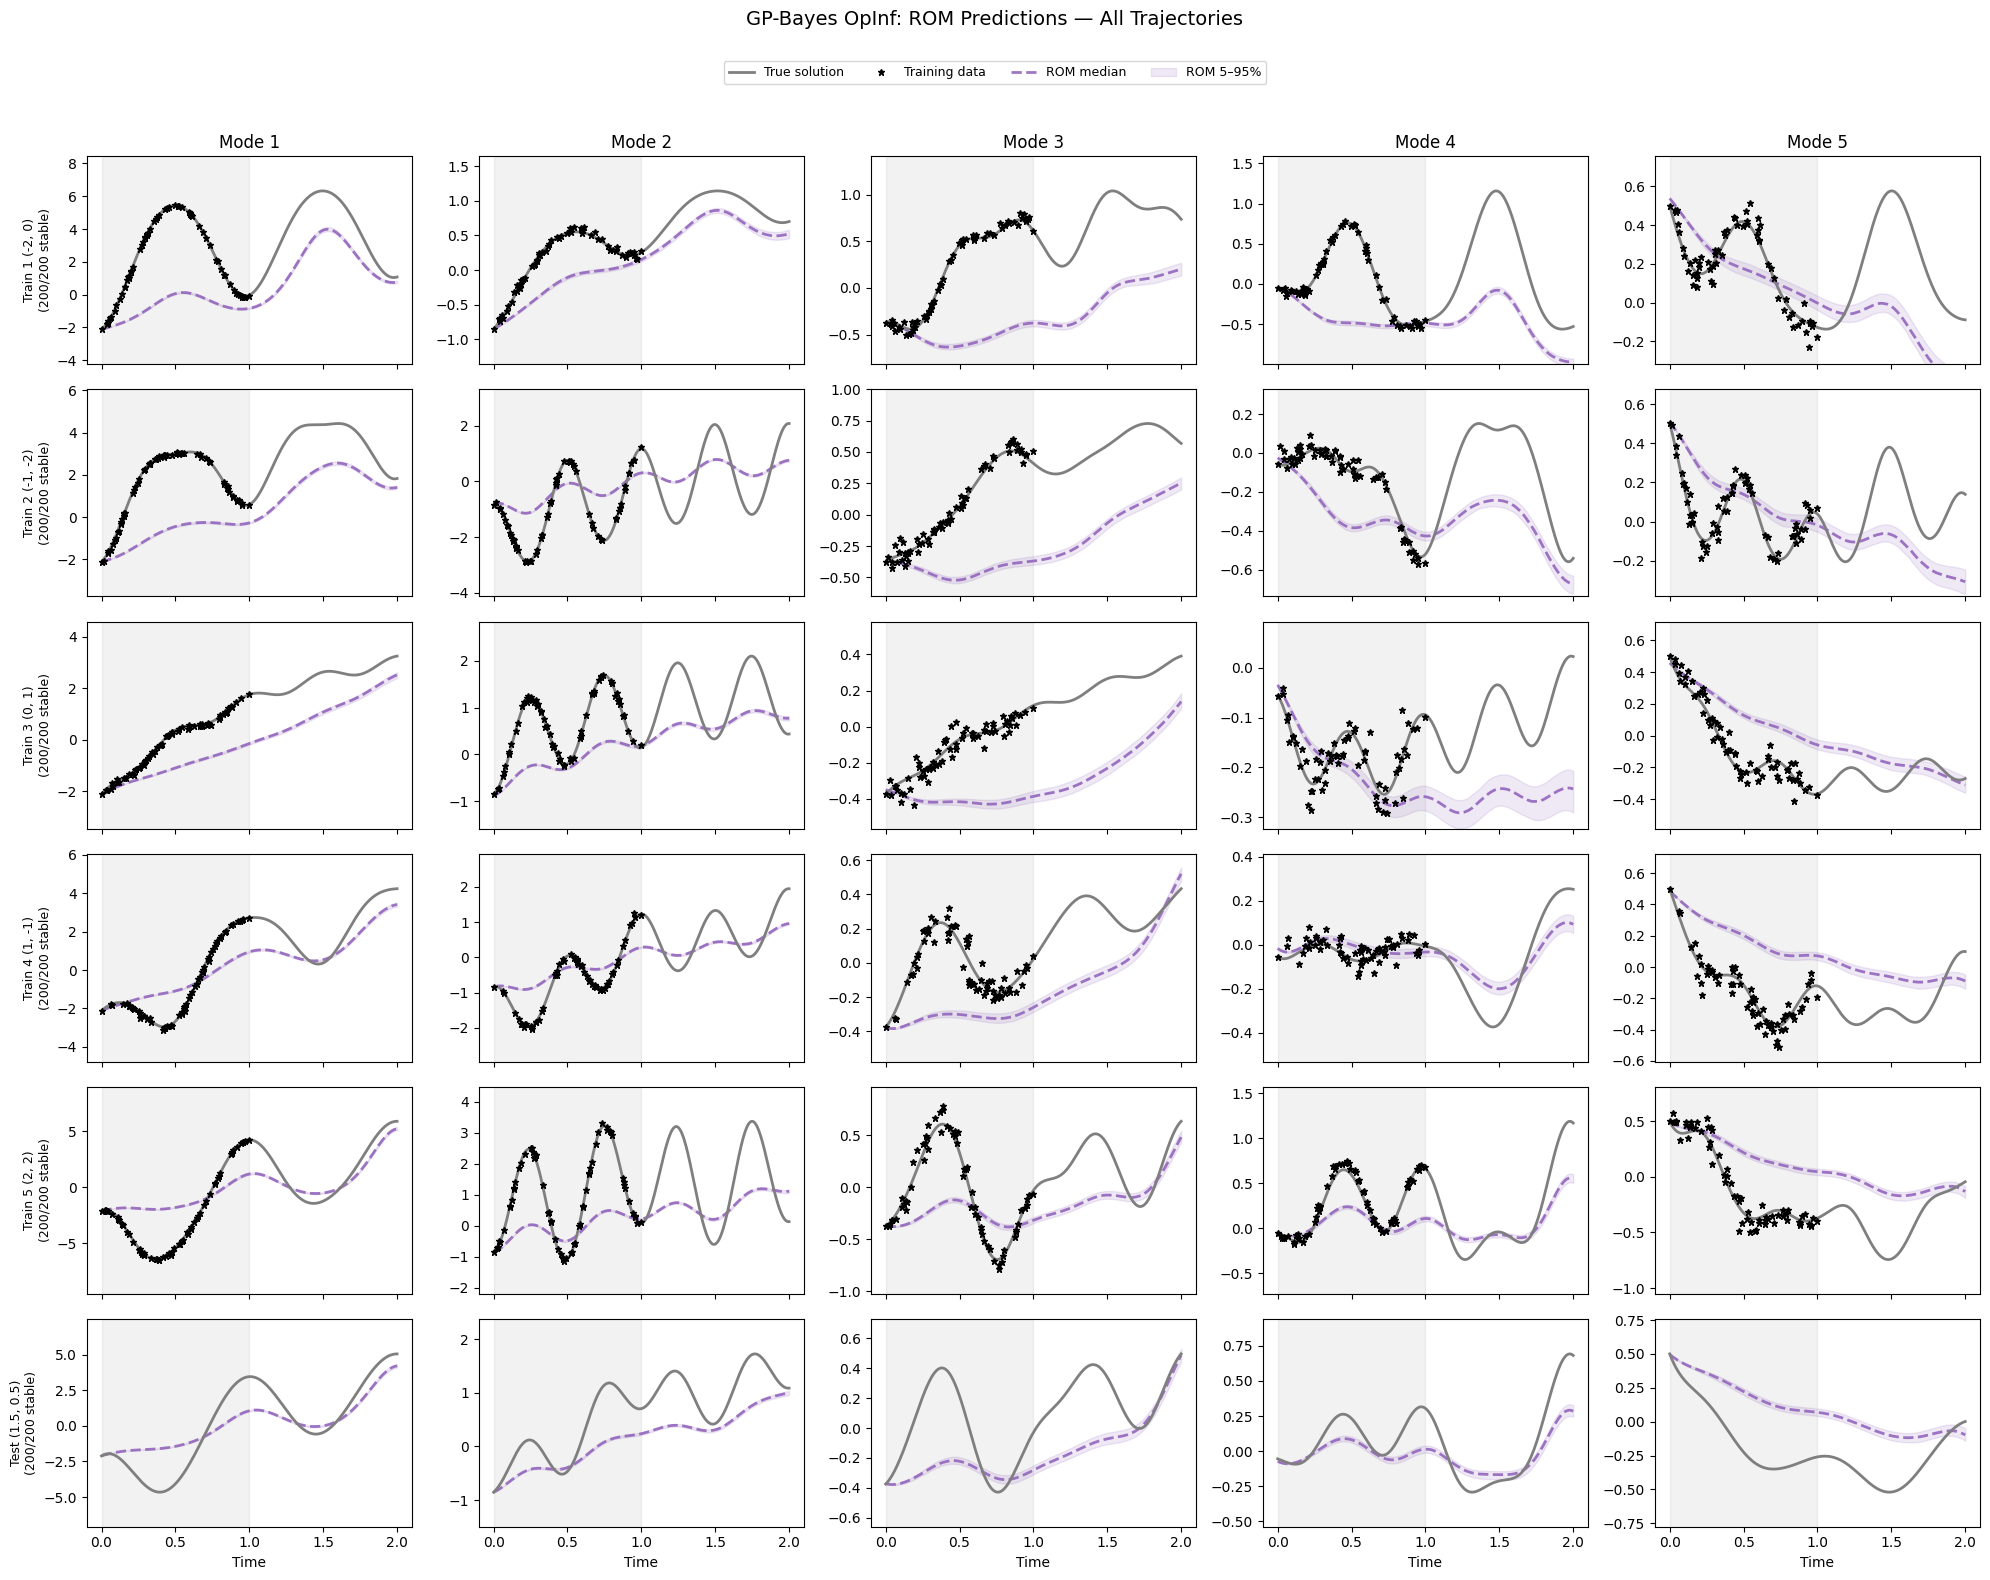


Stable draws per trajectory: 200/200


In [56]:
# Plot posterior samples — multi-trajectory grid matching Full Bayesian style
import heat_plotter
import importlib
importlib.reload(heat_plotter)

# Build trajectory metadata (matching 02_full_bayesian's _build_trajectories)
trajectories = []
for ic_idx in range(num_initial_conditions):
    trajectories.append({
        'label': f'Train {ic_idx+1} {config.input_parameters[ic_idx]}',
        'snapshots': snapshots_compressed[ic_idx],
        'time_snapshots': time_domain_sampled[ic_idx],
        'true_compressed': full_states_compressed[ic_idx],
        'time_true': time_domain,
    })
trajectories.append({
    'label': f'Test {config.test_parameters}',
    'snapshots': None,
    'time_snapshots': None,
    'true_compressed': full_states_compressed_new_initial,
    'time_true': time_domain,
})

n_traj = len(trajectories)
n_modes = numPODmodes
figsize = (4 * n_modes, 2.5 * n_traj)

fig, axes = plt.subplots(n_traj, n_modes, figsize=figsize, sharex=True, squeeze=False)

for row, traj in enumerate(trajectories):
    # Slice draws for this trajectory
    rom_solves = prediction_draws_compressed[:, row]  # (draws, modes, time)
    n_stable = len(rom_solves)

    for col in range(n_modes):
        ax = axes[row, col]

        # Training span shading
        ax.axvspan(training_span[0], training_span[1], color='gray', alpha=0.10, zorder=0)

        # True solution
        if traj.get('true_compressed') is not None and traj.get('time_true') is not None:
            ax.plot(traj['time_true'], traj['true_compressed'][col],
                    color='tab:gray', lw=2,
                    label='True solution' if (row == 0 and col == 0) else None)

        # Training data
        if traj.get('snapshots') is not None and traj.get('time_snapshots') is not None:
            ax.plot(traj['time_snapshots'], traj['snapshots'][col],
                    'k*', ms=5, zorder=5,
                    label='Training data' if (row == 0 and col == 0) else None)

        # ROM predictions (median + 5-95% CI)
        pred_time = sampler.prediction_time_domain
        if n_stable > 0:
            ax.plot(pred_time, np.median(rom_solves[:, col, :], axis=0),
                    color='tab:purple', linestyle='--', alpha=0.9, lw=2,
                    label='ROM median' if (row == 0 and col == 0) else None, zorder=0)
            ax.fill_between(pred_time,
                            np.percentile(rom_solves[:, col, :], 5, axis=0),
                            np.percentile(rom_solves[:, col, :], 95, axis=0),
                            color='tab:purple', alpha=0.15,
                            label='ROM 5\u201395%' if (row == 0 and col == 0) else None, zorder=0)

        if row == 0:
            ax.set_title(f'Mode {col + 1}')
        if col == 0:
            ax.set_ylabel(f'{traj["label"]}\n({n_stable}/{ndraws} stable)', fontsize=9)
        if row == n_traj - 1:
            ax.set_xlabel('Time')

        # Fix y-axis to truth for cross-method comparison
        if traj.get('true_compressed') is not None:
            from core.plotting import _ylim_from_truth
            ax.set_ylim(*_ylim_from_truth(traj['true_compressed'][col]))

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=len(handles), fontsize=9, bbox_to_anchor=(0.5, 1.02))

fig.suptitle('GP-Bayes OpInf: ROM Predictions — All Trajectories', fontsize=14, y=1.05)
fig.tight_layout()
if SAVE_PAPER_FIGURES:
    save_paper_figure(fig, f"heat_{PAPER_SCENARIO}_gpbo", PAPER_FIGURES_DIR)
plt.show()

print(f"\nStable draws per trajectory: {prediction_draws_compressed.shape[0]}/{ndraws}")
